In [1]:
from pathlib import Path
import os
import sys

# Make repo imports work even when the kernel starts inside a notebook subdirectory.
_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / 'configs' / 'profiles.py').exists():
    _repo_root = _repo_root.parent
if not (_repo_root / 'configs' / 'profiles.py').exists():
    raise RuntimeError("Failed to locate MADRL_ESS repo root containing configs/profiles.py.")
_repo_root_str = str(_repo_root)
if _repo_root_str not in sys.path:
    sys.path.insert(0, _repo_root_str)
os.chdir(_repo_root)


# Global MISOCP

直接按 canonical 3-agent 配置生成全局 MISOCP 测试结果，并写入 `notebooks/record/mpc/global_misocp/`。

In [2]:

from pprint import pprint

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from configs.profiles import compose_experiment_config, project_root, summarize_experiment
from predictors.mainline_forecast import get_mainline_forecast_controls
from scripts.mainline_compare import collect_global_full_horizon_rollout, compare_rollout_metrics
from scripts.utils.grid_notebook_workflow import (
    COMPARISON_WINDOW_CONTRACT,
    apply_notebook_experiment_settings,
    bootstrap_madrl_notebook_shared_data,
    build_comparison_cfg,
    plot_battery_power_and_soc_comparison,
    plot_global_misocp_validation,
    plot_net_load_comparison,
    plot_power_balance_comparison,
    plot_price_prediction_comparison,
    plot_voltage_profile_comparison,
    resolve_comparison_episode_window,
    resolve_episode_indices_for_start_timestamps,
    save_rollout_record,
)
from scripts.utils.torch_runtime import configure_torch_runtime


In [3]:

root = project_root()
window_cfg = compose_experiment_config(forecast_type='lstm', data_dir=root / 'data', runtime_mode='performance', seed=0)
forecast_controls = get_mainline_forecast_controls(auto_train_missing=False)
apply_notebook_experiment_settings(window_cfg, prediction_mode='normal', test_start_date=None, test_end_date=None, agent_profiles=None, agent_bus_ids=None, load_scale=None, pv_scale=None, future_horizon=int(forecast_controls['future_horizon']), battery_controls=None, forecast_controls=forecast_controls, train_year=None, test_year=None)
window_cfg.forecast.auto_train_missing = False
bootstrap_madrl_notebook_shared_data(window_cfg, root=root, notebook_path='notebooks/madrl/global_MISOCP.ipynb')
comparison_window = resolve_comparison_episode_window(window_cfg)
episode_start_timestamps = list(comparison_window['episode_start_timestamps'])

misocp_solve_cfg = build_comparison_cfg(window_cfg, prediction_mode='perfect')
misocp_solve_cfg.data.test_start_date = None
misocp_solve_cfg.data.test_end_date = None
misocp_episode_indices = resolve_episode_indices_for_start_timestamps(misocp_solve_cfg, episode_start_timestamps)
runtime_state = configure_torch_runtime(misocp_solve_cfg, seed=misocp_solve_cfg.runtime.seed)
misocp_solve_cfg.runtime.device = runtime_state.device
rollout = collect_global_full_horizon_rollout(
    misocp_solve_cfg,
    label='Global MISOCP',
    episode_indices=misocp_episode_indices,
)
misocp_window_meta = {'comparison_window_contract': COMPARISON_WINDOW_CONTRACT, 'episode_start_timestamps': episode_start_timestamps, 'backend_episode_indices': misocp_episode_indices}
save_rollout_record(rollout, category='mpc', scheme_name='global_misocp', root=root, config_snapshot={'window_cfg_summary': summarize_experiment(window_cfg), 'solve_cfg_summary': summarize_experiment(misocp_solve_cfg), 'prediction_mode': 'perfect', **misocp_window_meta}, extra_meta=misocp_window_meta)
metrics_df = compare_rollout_metrics(rollout)
display(metrics_df)
pprint({'record_dir': str(root / 'notebooks' / 'record' / 'mpc' / 'global_misocp')})


D:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[


D:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[


D:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[


D:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[


D:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[


...

{

'record_dir'

: 

'D:\\GithubProject\\MADRL_ESS\\notebooks\\record\\mpc\\global_misocp'

}

1. 电力电量平衡

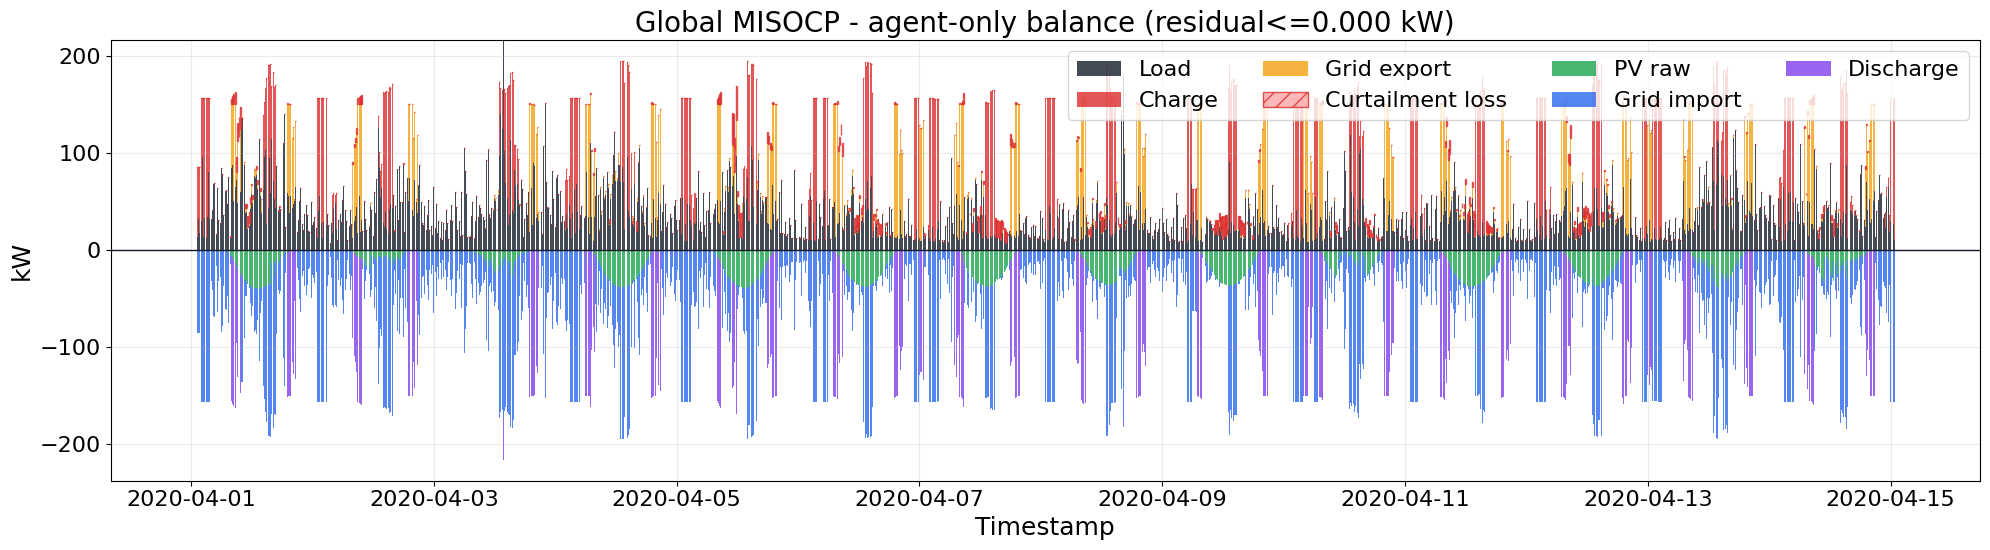

2. 电价

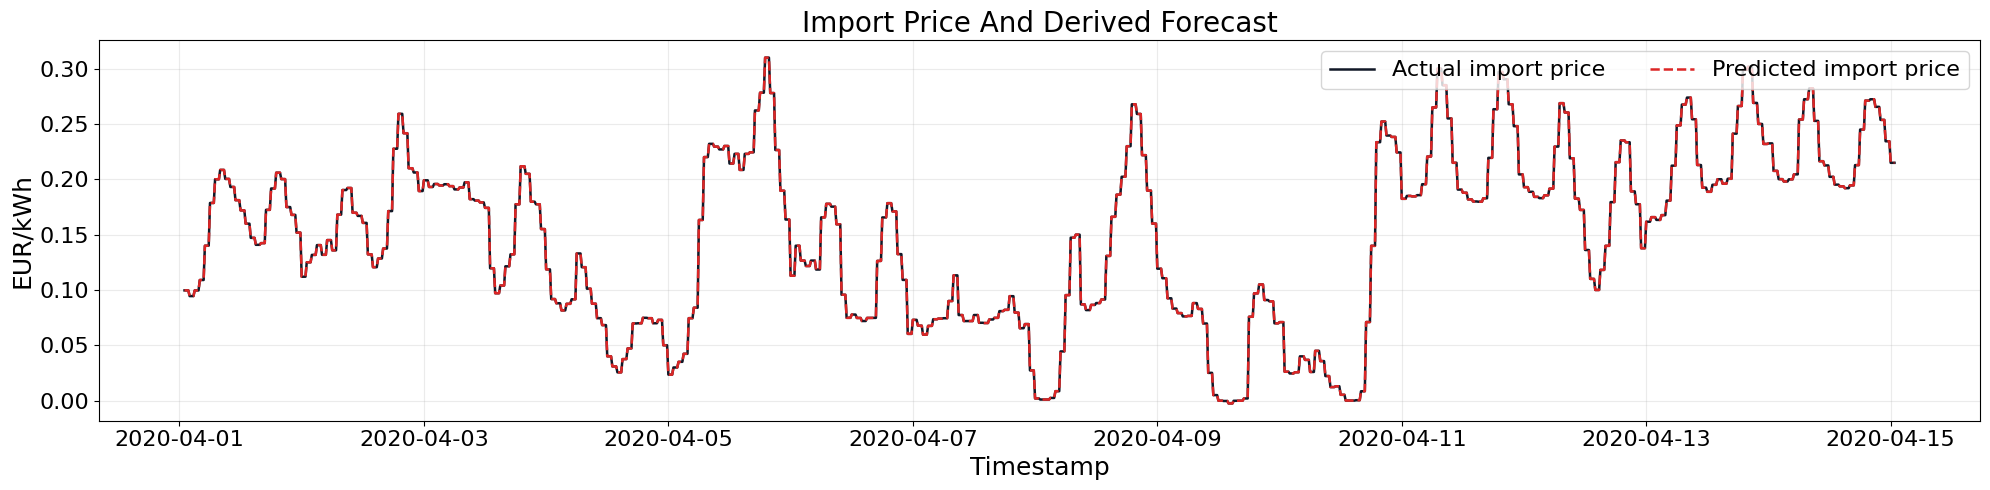

3. 总体储能充放功率与 SoC

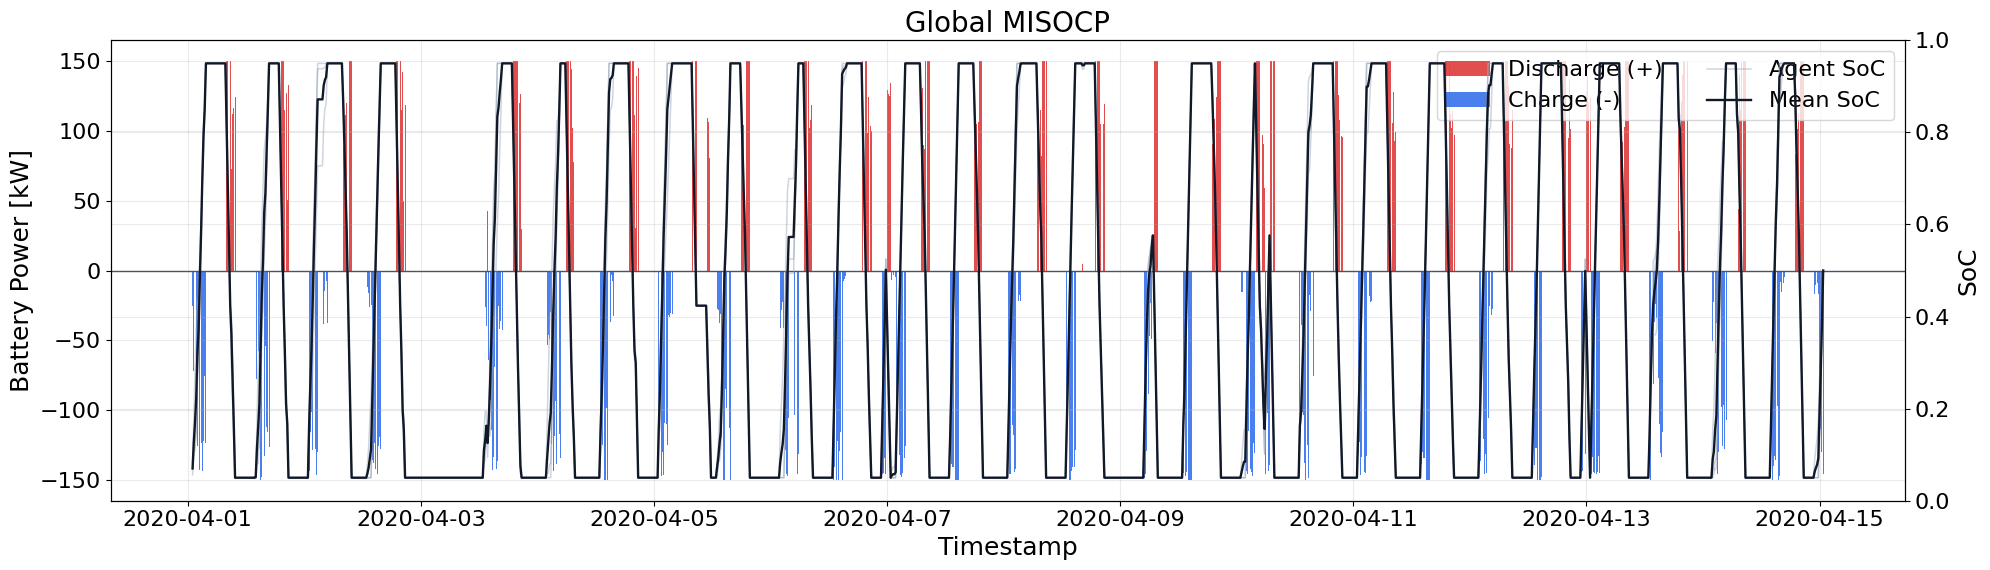

4. 电压

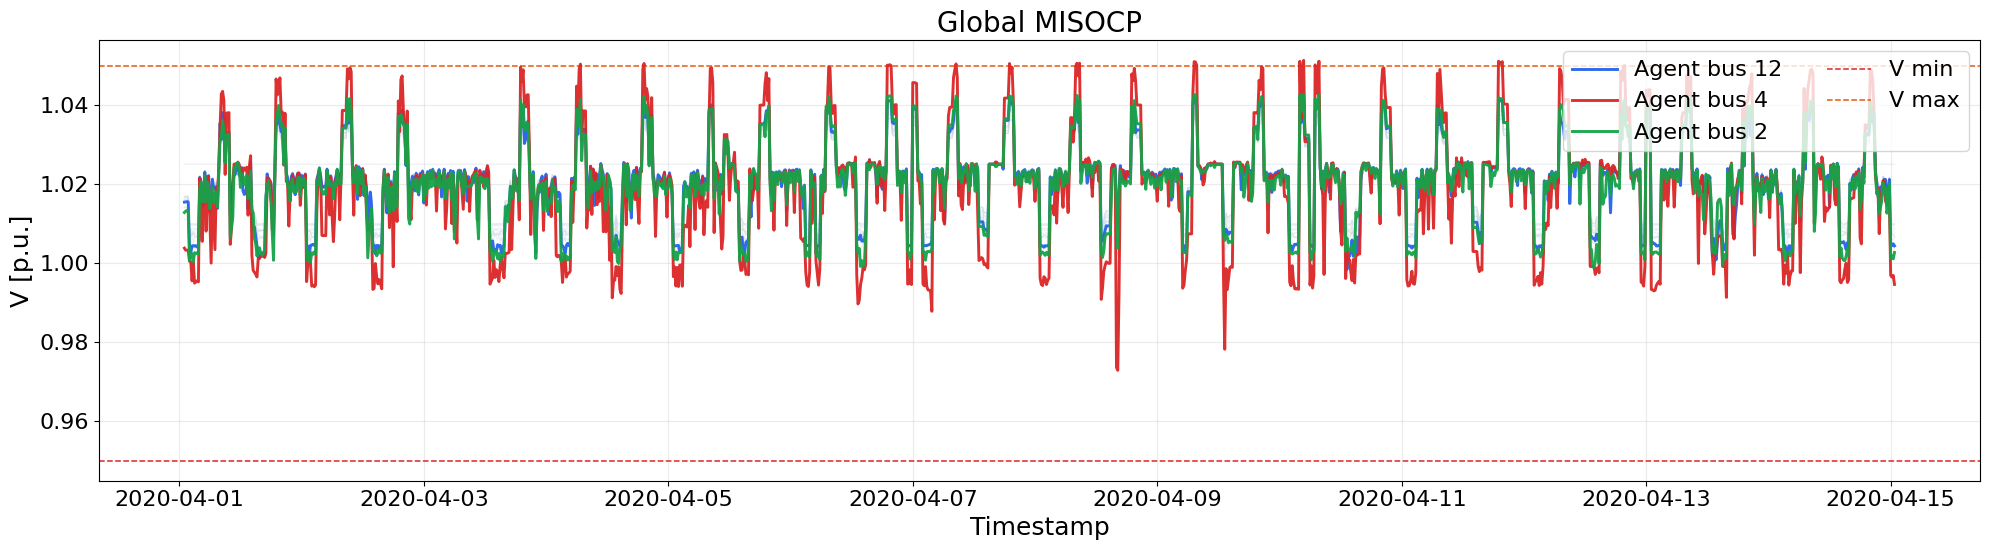

5. 净负荷

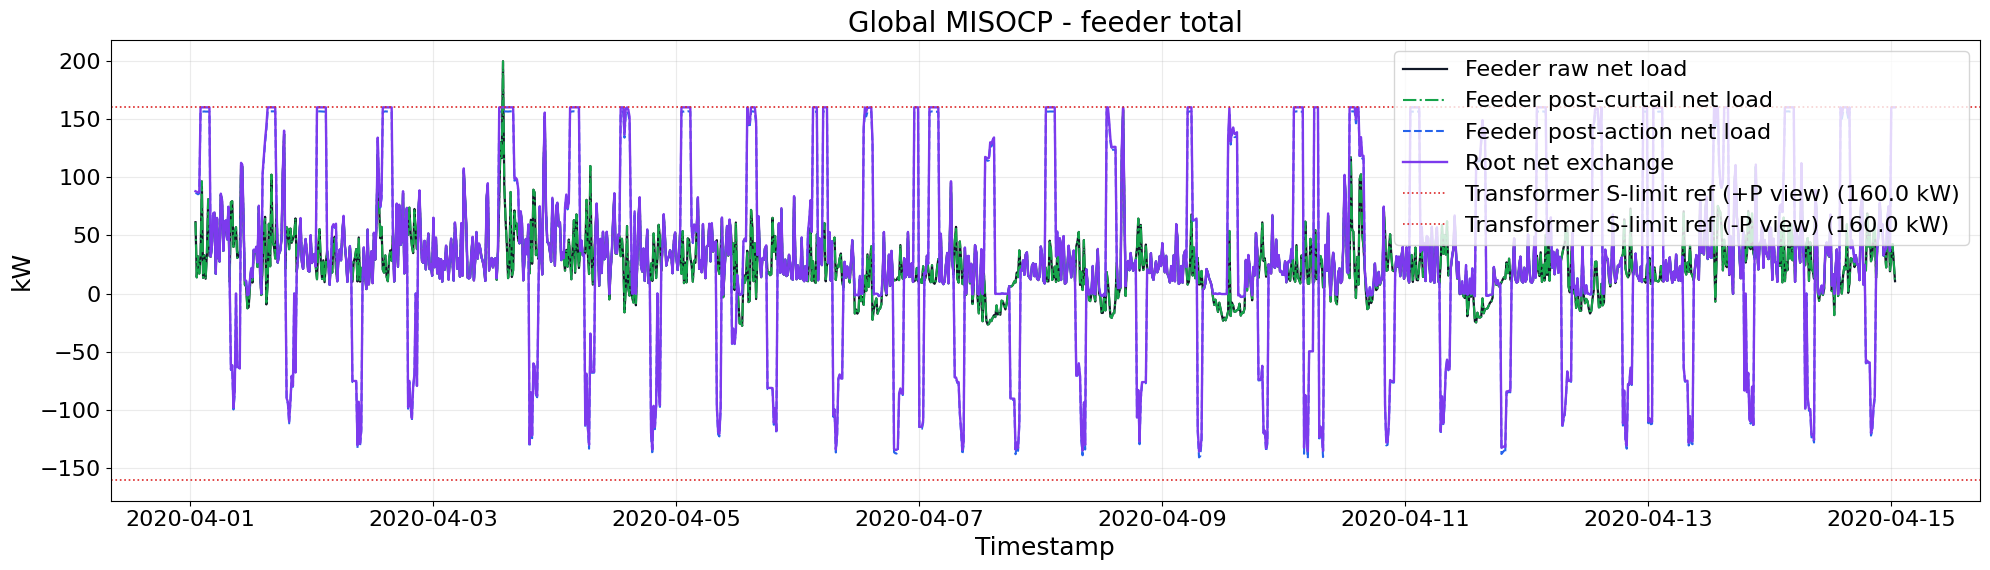

In [4]:

# 统一展示 Global MISOCP 的关键图，便于单 notebook 直接验收结果。
_plot_specs = [
    ('1. 电力电量平衡', plot_power_balance_comparison),
    ('2. 电价', plot_price_prediction_comparison),
    ('3. 总体储能充放功率与 SoC', plot_battery_power_and_soc_comparison),
    ('4. 电压', plot_voltage_profile_comparison),
    ('5. 净负荷', plot_net_load_comparison),
]

for title, plot_fn in _plot_specs:
    print(title)
    figure = plot_fn(rollout)
    display(figure)
    plt.close(figure)


,value
global_oracle_status_label,optimal
global_oracle_gap,0.004964
global_oracle_target_gap,0.005
misocp_simultaneous_step_ratio,0.0
steps_outside_tolerance,769
p95_soc_slack,0.000715
max_solver_feeder_gap_kw,6.727737
max_replay_feeder_gap_kw,7.210587
root_p_fit_interpretation,consistent


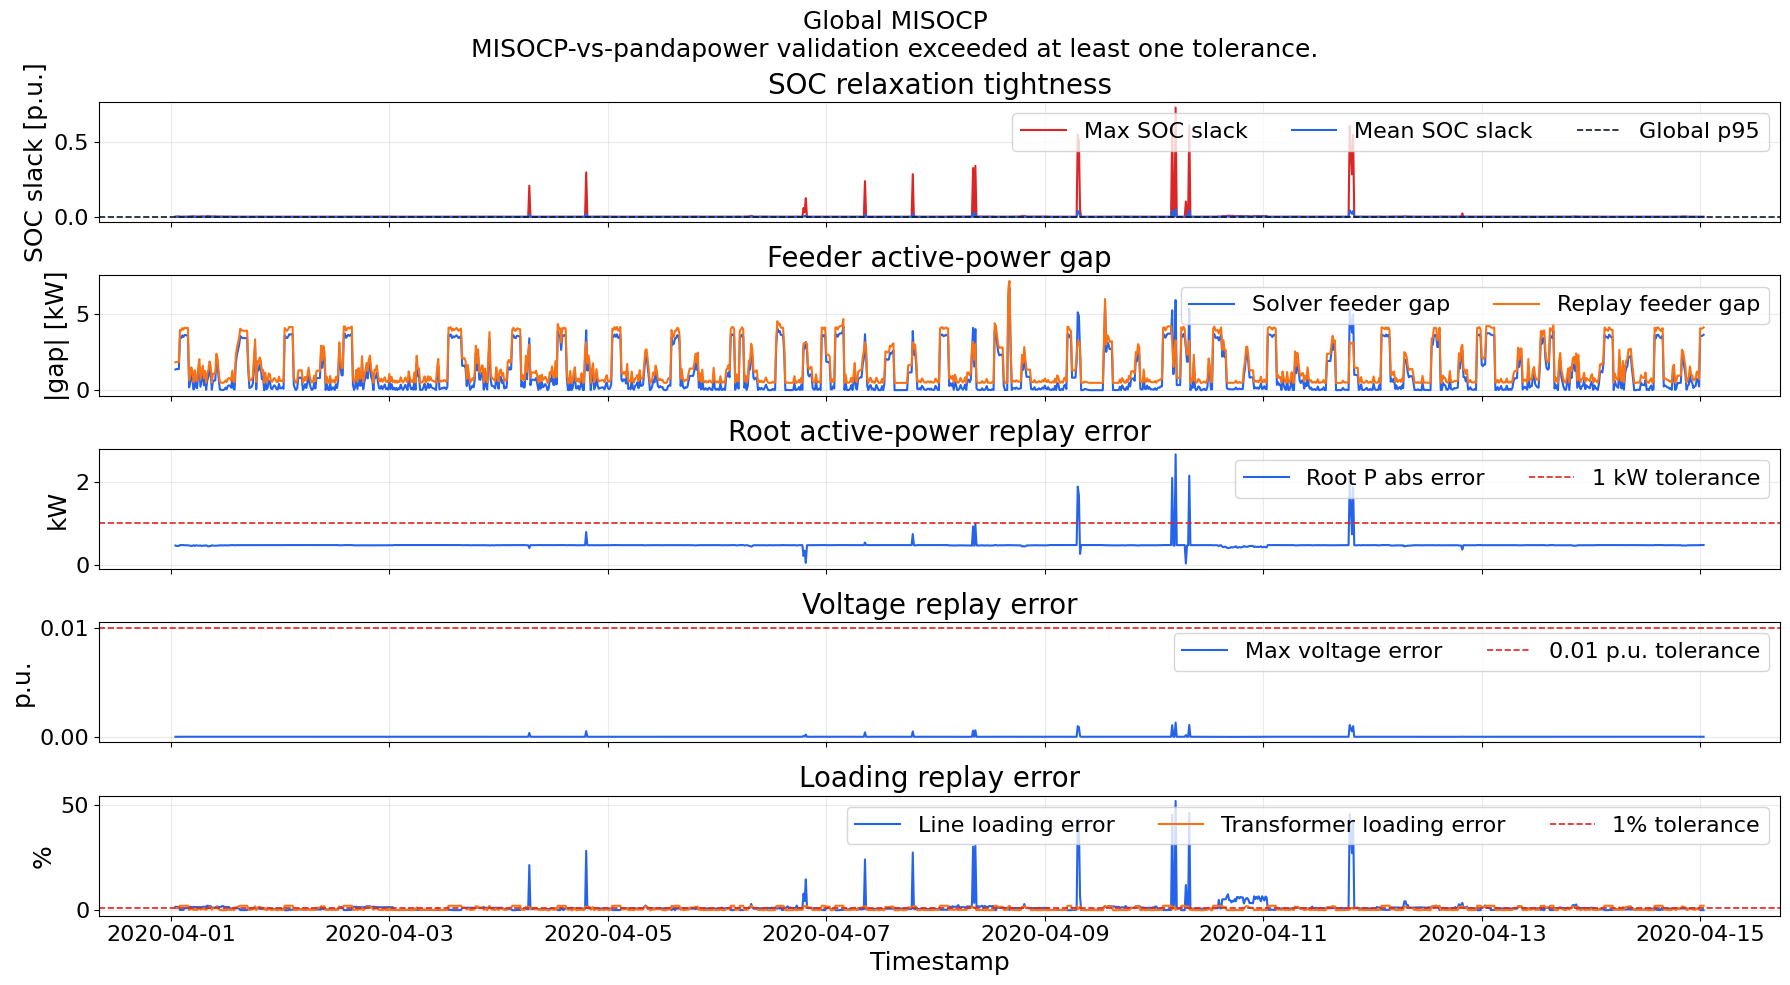

In [5]:

# MISOCP 专属诊断：先看求解 gap，再看 SOCP 松弛和功率 replay 误差。
_validation_summary = rollout.meta['misocp_validation_summary']
_misocp_gap_summary = pd.Series(
    {
        'global_oracle_status_label': rollout.meta['global_oracle_status_label'],
        'global_oracle_gap': float(rollout.meta['global_oracle_gap']),
        'global_oracle_target_gap': float(rollout.meta['global_oracle_target_gap']),
        'misocp_simultaneous_step_ratio': float(rollout.meta['misocp_simultaneous_step_ratio']),
        'steps_outside_tolerance': int(_validation_summary['steps_outside_tolerance']),
        'p95_soc_slack': float(_validation_summary['p95_soc_slack']),
        'max_solver_feeder_gap_kw': float(_validation_summary['max_solver_feeder_gap_kw']),
        'max_replay_feeder_gap_kw': float(_validation_summary['max_replay_feeder_gap_kw']),
        'root_p_fit_interpretation': str(_validation_summary['root_p_fit_interpretation']),
    },
    name='global_misocp_gap_and_tightness',
)
display(_misocp_gap_summary.to_frame('value'))

_misocp_validation_fig = plot_global_misocp_validation(rollout)
display(_misocp_validation_fig)
plt.close(_misocp_validation_fig)
